# Проект: Исследовательский анализ данных о бронировании билетов сервиса Яндекс Афиша.
- Автор: Перескоков Сергей
- Дата: 26.02.2026

## Введение
Цель: На основе представленных данных изучить общее изменение в пользовательском спросе.

Задачи и подзадачи:
1. загрузить и ознакомиться с предоставленными данными:
    - загрузить данные
    - оценить их объем и корректность
    - сделать промежуточный вывод
    
    
2. провести предобработку данных:
    - проверить данные на пропуски
    - изучить значения в столбцах и обработать их в случае необходимости
    - проверить наличие явных и неявных дубликатов
    - преобразовать типы данных (отдельное внимание уделить датам и размерности этих данных)
    - создать столбцы: revenue_rub, one_ticket_revenue_rub, month, season
    - сделать промежуточный вывод
    
    
3. провести исследовательский анализ исходных данных:
    - провести анализ распределения заказов по сегментам и их сезонные изменения
    - провести анализ осенней активности пользователей
    - изучить данные по популярным событиям в разрезе регионов и партнеров
    - сделать промежуточный вывод
    
    
4. провести статистический анализ данных:
    - сформулировать гипотезы
    - подобрать подходящий статистический тест
    - провести статистический анализ
    - сделать промежуточный вывод
    
    
5. сделать итоговые выводы и написать рекомендации:
    - описать данные с которыми велась работа
    - сформулировать основные результаты анализа
    - прокомментировать результаты проверки гипотез
    - предложить рекомендации, на что стоит обратить внимание в первую очередь

## Описание данных
Представленные данные содержат три датасета: final_tickets_orders_df.csv, final_tickets_events_df.csv, final_tickets_tenge_df.csv

1. Данные датасета final_tickets_orders_df.csv:
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.
- days_since_prev - количество дней с предыдущей покупки для каждого пользователя. 


2. Данные датасета final_tickets_events_df:
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.

3. Данные датасета final_tickets_tenge_df.csv:
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).

## Загрузка и ознакомление с данными

In [ ]:
# Ячейка для хранения используемых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [ ]:
# Загрузим все необходимые для работы датасеты
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
df_tickets_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [ ]:
# Выведем каждый датасет, чтобы убедиться в корректности содержания и проверить наличие пропусков.
display(df_orders)
display(df_orders.info())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290844,368620,fffcd3dde79eb2c,2024-10-27,2024-10-27 18:00:57,33189,нет,6,rub,mobile,965.57,Весь в билетах,4,9655.73,0.0
290845,368562,fffcd3dde79eb2c,2024-10-27,2024-10-27 17:53:53,33189,нет,6,rub,mobile,1448.36,Весь в билетах,6,14483.60,0.0
290846,8473772,fffcd3dde79eb2c,2024-10-30,2024-10-30 13:37:43,205231,нет,16,rub,desktop,178.95,Прачечная,2,4473.74,3.0
290847,5526067,fffeeb3c120cf0b,2024-09-24,2024-09-24 10:07:42,454526,нет,18,rub,desktop,661.53,Билеты без проблем,2,6615.34,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

None

In [ ]:
display(df_events)
display(df_events.info())

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"
...,...,...,...,...,...,...,...,...,...,...,...
22422,591313,196f51a8-344a-462a-b806-a8467fd0e5fa,спортивное мероприятие,спорт,№1623,Речиновская область,Дальнесветск,65,3721,"Студия графики ""Оттенок"" Инк","ул. Чапаева, д. 8 стр. 1/3"
22423,591859,b2b83233-f861-496c-b6fb-a4fef347deb1,ёлка,ёлки,№1992,Солнечноземская область,Глинополье,56,3005,"Арт-кафе ""Аксессуар"" Лимитед","бул. Логовой, д. 94 к. 1/5"
22424,591877,6bffa2da-51d1-4cfe-accb-a02e617a8180,событие,другое,№1767,Североключевской округ,Ягодинска,21702,3506,"Клуб современных танцев ""Кофе"" Групп","ш. Тупиковое, д. 49 стр. 73"
22425,592322,9283cb32-2750-43cd-b57e-dde9ccd5552e,событие,другое,№3884,Яблоневская область,Светополье,39,1081,"Искусственная сцена ""Краски"" и партнеры","пер. Р.Люксембург, д. 499 к. 997"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


None

In [ ]:
display(df_tickets_tenge)
display(df_tickets_tenge.info())

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


None

In [ ]:
# Проверим данные на наличие пропусков в каждом датафрейме
df_orders.isnull().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

In [ ]:
df_events.isnull().sum()

event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

In [ ]:
df_tickets_tenge.isnull().sum()

data       0
nominal    0
curs       0
cdx        0
dtype: int64

Промежуточный вывод.

Датафрейм df_orders содержит 290849 строк и 14 столбцов. Присутствуют пропуски в days_since_prev в количестве 21940. Однако как известно из представленных данных пропуски в данном столбце могут возникнуть, если у покупателя не былло предыдущих покупок. В связи с этим данные пропуски не являются критичными для анализа данных.

Датафрейм df_events содержит 22427 строк и 11 столбцов. Пропусков не установлено.

Датафрейм df_tickets_tenge содержит 357 строк и 4 столбца. Пропусков не установлено.

Предварительно все названия столбцов соответствуют их содержанию. Данные пригодны для дальнейшей обработки.


## Предобработка данных

In [ ]:
# Проверим столбцы с категориальными значениями и ознакомимся с их содержанием.
df_orders['cinema_circuit'].value_counts()

нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

In [ ]:
df_orders['currency_code'].value_counts()

rub    285780
kzt      5069
Name: currency_code, dtype: int64

In [ ]:
df_orders['device_type_canonical'].value_counts()

mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64

In [ ]:
df_orders['service_name'].value_counts()

Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                   67
Цвет и б

В датафрейме df_orders категориальные данные не имеют неявных дублей в категориях. df_orders['cinema_circuit'] имеет 289451 значений 'нет' указывающих на отсутствие принадлежности к сети кинотеатров.

In [ ]:
df_events['event_type_description'].value_counts()

концерт                   8485
спектакль                 6015
событие                   4530
шоу                        731
спортивное мероприятие     575
балет                      484
мюзикл                     359
спорт                      297
опера                      252
фестиваль                  212
выставка                   209
ёлка                       157
цирковое шоу               112
экскурсия                    3
оперетта                     1
снегурочка                   1
кукольный спектакль          1
музыкальный спектакль        1
подарок                      1
рок-мюзикл                   1
Name: event_type_description, dtype: int64

df_events['event_type_description'] содержит ряд событий, которые встречаются по 1 разу. Считаем, что исходя из названий типов мероприятий, присутствуют неявные дубликаты в данном столбце. Предлагаю 'спорт' объединить со 'спортивным мероприятием', 'музыкальный спектакль' объединить со 'спектакль', 'рок-мюзикл' объединить с 'мюзикл', 'кукольный спектакль' объединить со 'спектакль', 'опера' объединить с 'оперетта'. Считаем, что так избавимся от неявных дубликатов, но учтем их в данных.

У нас остаются категории 'Снегурочка' и 'Подарок', которые без контекста нельзя отнести ни к одной из категорий. Выведем их и посмотрим куда можно их отнести исходя из контекста.

In [ ]:
df_events[df_events['event_type_description'] == 'подарок']

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
19072,564916,09a3dac3-5afc-472a-9a51-ba9f8b6901ca,подарок,другое,№4477,Каменевский регион,Глиногорск,213,2059,"Школа кино ""Джунгли"" Инк","пр. Юности, д. 17"


In [ ]:
df_events[df_events['event_type_description'] == 'снегурочка']

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
18227,560404,05c5ee93-4b12-4685-ae16-7ebec12801d1,снегурочка,другое,№4837,Каменевский регион,Глиногорск,213,3470,"Клуб киноманов ""Верность"" Лтд","пр. Титова, д. 5 стр. 68"


Мы вывели данные строки, решаем объединить данные категории с категорией 'событие'.

In [ ]:
# Изменим датасет, объединим категории, которые мы посчитали неявными дубликатами, с другими категориями исходя из контекста данных.
replace_map = {
    'спорт': 'спортивное мероприятие',
    'музыкальный спектакль': 'спектакль',
    'рок-мюзикл': 'мюзикл',
    'кукольный спектакль': 'спектакль',
    'оперетта': 'опера',
    'снегурочка': 'событие',
    'подарок': 'событие'
}
df_events['event_type_description'] = df_events['event_type_description'].replace(replace_map)
print(df_events['event_type_description'].value_counts())

концерт                   8485
спектакль                 6017
событие                   4532
спортивное мероприятие     872
шоу                        731
балет                      484
мюзикл                     360
опера                      253
фестиваль                  212
выставка                   209
ёлка                       157
цирковое шоу               112
экскурсия                    3
Name: event_type_description, dtype: int64


In [ ]:
# Проверка итогового датасета по столбцу 'event_type_main'
df_events['event_type_main'].value_counts()

концерты    8680
театр       7076
другое      4658
спорт        872
стендап      636
выставки     290
ёлки         215
Name: event_type_main, dtype: int64

Таким образом в датасете df_events были обнаружены неявные дубликаты в столбце 'event_type_description', произведено изменение категорий исходя из конкекста данных. Мы проверили все столбцы с категорияальными данными и переходим к дальнейшей предобработке данных. Неявных дубликатов в столбцах с категориальными данными, кроме 'event_type_description' не установлено.

In [ ]:
# Мы решиди провести анализ категориальных данных в двух разных датафреймах. Далее для удобства работы мы объединим два датафрейма в один.
data = pd.merge(df_orders, df_events, on='event_id', how='outer')

In [ ]:
# Проверим наличие явных дубликатов в двух датафреймах (объединенном и том, где содержатся данные о курсе тенге)
data.duplicated().sum()

0

In [ ]:
df_tickets_tenge.duplicated().sum()

0

Явных дубликатов не обнаружено ни в одном датафрейме. Переходим к дальнейшей предобработке данных

In [ ]:
# Разделим объединенный датафрейм на два по валюте.
data_rub = data[data['currency_code'] == 'rub']
data_kzt = data[data['currency_code'] == 'kzt']

In [ ]:
# Выведем общую описательную статистику по датафреймам.
print("Рубли:\n", data_rub[['revenue', 'tickets_count']].describe())
print("\nТенге:\n", data_kzt[['revenue', 'tickets_count']].describe())

Рубли:
              revenue  tickets_count
count  285780.000000  285780.000000
mean      547.568333       2.754077
std       871.524559       1.171419
min       -90.760000       1.000000
25%       113.827500       2.000000
50%       346.100000       3.000000
75%       791.700000       4.000000
max     81174.540000      57.000000

Тенге:
             revenue  tickets_count
count   5069.000000    5069.000000
mean    4995.206767       2.762872
std     4916.752776       1.115558
min        0.000000       1.000000
25%      518.100000       2.000000
50%     3698.830000       3.000000
75%     7397.660000       4.000000
max    26425.860000       6.000000


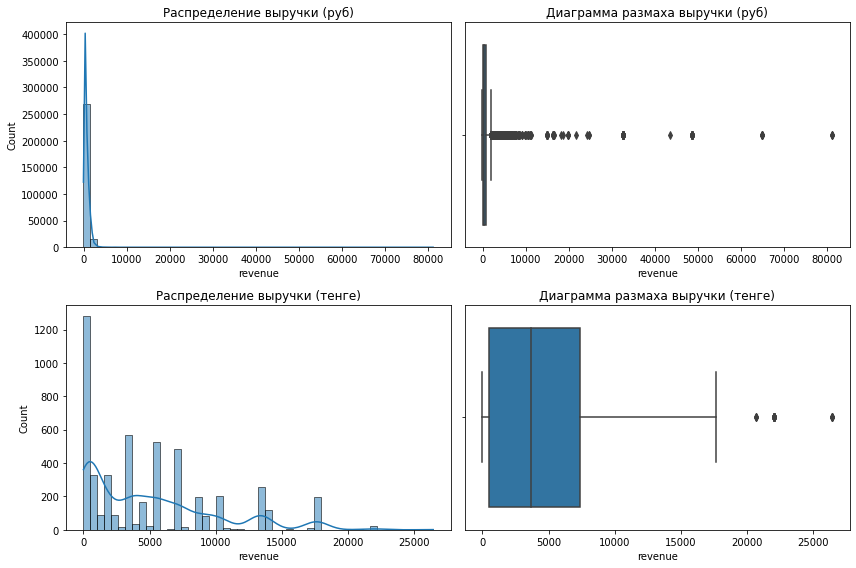

In [ ]:
# Создадим график распределения выручки по двум валютам
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# revenue - рубли
sns.histplot(data_rub['revenue'], bins=50, ax=axes[0,0], kde=True)
axes[0,0].set_title("Распределение выручки (руб)")

sns.boxplot(x=data_rub['revenue'], ax=axes[0,1])
axes[0,1].set_title("Диаграмма размаха выручки (руб)")

# revenue - тенге
sns.histplot(data_kzt['revenue'], bins=50, ax=axes[1,0], kde=True)
axes[1,0].set_title("Распределение выручки (тенге)")

sns.boxplot(x=data_kzt['revenue'], ax=axes[1,1])
axes[1,1].set_title("Диаграмма размаха выручки (тенге)")

plt.tight_layout()
plt.show()

Из распределений видно, что присутствуют значетельные выбросы с большую сторону, в связи с чем принимаем решения выбрать из данных только те, которые относятся к 99-му процентилю.

In [ ]:
# Находим 99-й процентиль
p99_rub = data_rub['revenue'].quantile(0.99)
p99_kzt = data_kzt['revenue'].quantile(0.99)

# фильтруем 99-й процентиль
df_rub_clean = data_rub[data_rub['revenue'] <= p99_rub]
df_kzt_clean = data_kzt[data_kzt['revenue'] <= p99_kzt]

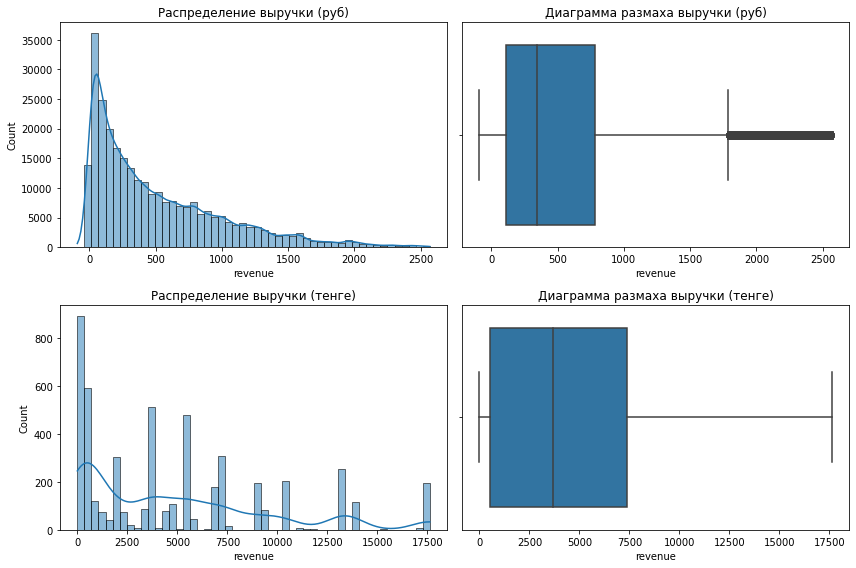

In [ ]:
# Снова строим диаграммы распределения выручки в двух валютах с учетом того, что мы удалили выбросы.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# revenue - рубли
sns.histplot(df_rub_clean['revenue'], bins=50, ax=axes[0,0], kde=True)
axes[0,0].set_title("Распределение выручки (руб)")

sns.boxplot(x=df_rub_clean['revenue'], ax=axes[0,1])
axes[0,1].set_title("Диаграмма размаха выручки (руб)")

# revenue - тенге
sns.histplot(df_kzt_clean['revenue'], bins=50, ax=axes[1,0], kde=True)
axes[1,0].set_title("Распределение выручки (тенге)")

sns.boxplot(x=df_kzt_clean['revenue'], ax=axes[1,1])
axes[1,1].set_title("Диаграмма размаха выручки (тенге)")

plt.tight_layout()
plt.show()

Как мы видим масштаб данных значиительно уменьшился, именно с этими данными мы будем работать далее.
Также кам требуется сделать визуализацию распределений по 'tickets_count'. Сначала мы визуализируем данные и посмотрим на наличие выбросов, в случае если они будут, также ограничим датафрейм только 99-м процентилем.

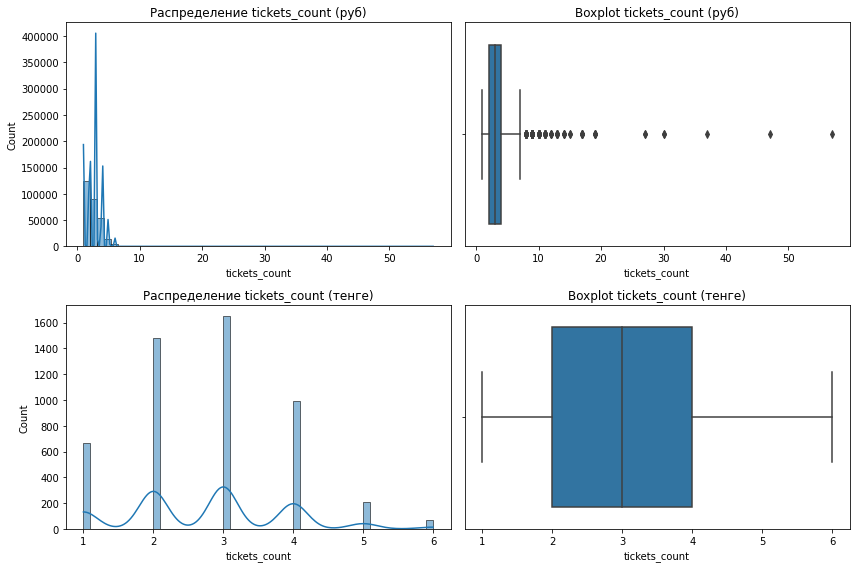

In [ ]:
# Визуализируем данные по 'tickets_count'
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# revenue - рубли
sns.histplot(data_rub['tickets_count'], bins=50, ax=axes[0,0], kde=True)
axes[0,0].set_title("Распределение tickets_count (руб)")

sns.boxplot(x=data_rub['tickets_count'], ax=axes[0,1])
axes[0,1].set_title("Boxplot tickets_count (руб)")

# revenue - тенге
sns.histplot(data_kzt['tickets_count'], bins=50, ax=axes[1,0], kde=True)
axes[1,0].set_title("Распределение tickets_count (тенге)")

sns.boxplot(x=data_kzt['tickets_count'], ax=axes[1,1])
axes[1,1].set_title("Boxplot tickets_count (тенге)")

plt.tight_layout()
plt.show()

Визуализация показываем, что как минимум в данных, относящихся к рублям, имеются выбросы. Далее мы также выделим 99-й процентиль, но принимаем решение сделать так как в данных с рублем, так и в данных с тенге.

In [ ]:
# 99-й процентиль
p99_rub = data_rub['tickets_count'].quantile(0.99)
p99_kzt = data_kzt['tickets_count'].quantile(0.99)

# фильтруем
df_rub_clean_tickets_count = data_rub[data_rub['tickets_count'] <= p99_rub]
df_kzt_clean_tickets_count = data_kzt[data_kzt['tickets_count'] <= p99_kzt]

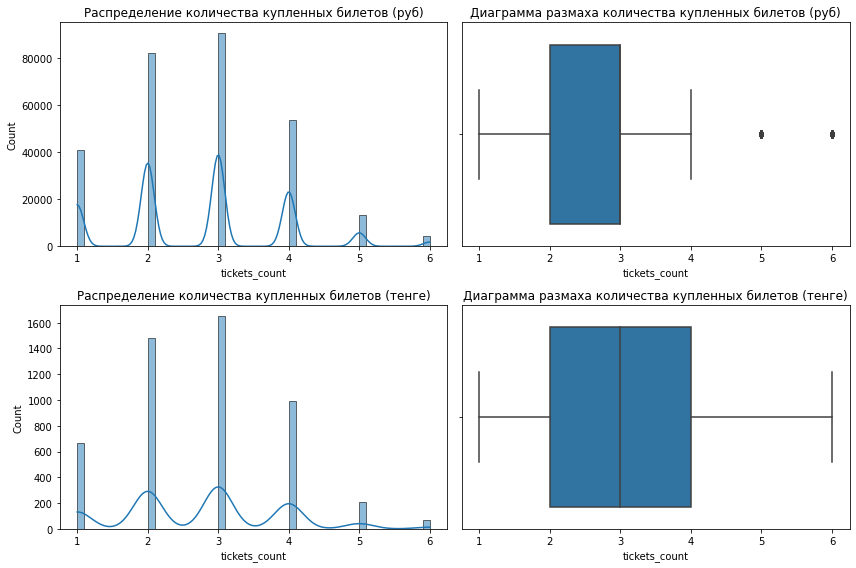

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# revenue - рубли
sns.histplot(df_rub_clean_tickets_count['tickets_count'], bins=50, ax=axes[0,0], kde=True)
axes[0,0].set_title("Распределение количества купленных билетов (руб)")

sns.boxplot(x=df_rub_clean_tickets_count['tickets_count'], ax=axes[0,1])
axes[0,1].set_title("Диаграмма размаха количества купленных билетов (руб)")

# revenue - тенге
sns.histplot(df_kzt_clean_tickets_count['tickets_count'], bins=50, ax=axes[1,0], kde=True)
axes[1,0].set_title("Распределение количества купленных билетов (тенге)")

sns.boxplot(x=df_kzt_clean_tickets_count['tickets_count'], ax=axes[1,1])
axes[1,1].set_title("Диаграмма размаха количества купленных билетов (тенге)")

plt.tight_layout()
plt.show()

Считаем, что представленные данные корректно отражают распределение количества купленных билетов с разрезе валют. Касательно самого распредления можно сказать что оно нормальное, однако имеет хвосты с правую сторону.

In [ ]:
# --- Фильтрация выбросов по 99-му процентилю ---
total_rows = len(data)

rev_threshold = data['revenue'].quantile(0.99)
tickets_threshold = data['tickets_count'].quantile(0.99)

# формируем очищенный датасет
data_clean = data[(data['revenue'] <= rev_threshold) & 
                  (data['tickets_count'] <= tickets_threshold)].copy()

cut_rows = total_rows - len(data_clean)
cut_share = cut_rows / total_rows * 100

print(f"Всего строк в исходном датасете: {total_rows}")
print(f"Осталось строк после фильтрации: {len(data_clean)}")
print(f"Срезано строк: {cut_rows} ({cut_share:.2f}% от исходного датасета)")

data = data_clean

Всего строк в исходном датасете: 290849
Осталось строк после фильтрации: 287755
Срезано строк: 3094 (1.06% от исходного датасета)


Ранее, когда мы знакомились с данными в таблицах, мы установили, что некоторые типы данных можно оптимизировать. Перейдем к оптимизиции данных в объединенном датафрейме data. 

In [ ]:
# Преобразование дат
data['created_dt_msk'] = pd.to_datetime(data['created_dt_msk']) 
data['created_ts_msk'] = pd.to_datetime(data['created_ts_msk'])

# Преобразование столбцов с категориальными данными
cat_cols = ['cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name', 
            'event_type_description', 'event_type_main', 'region_name', 'city_name', 'organizers']
for col in cat_cols:
    data[col] = data[col].astype('category')

# Целочисленные колонки
int_cols = ['order_id', 'event_id', 'age_limit', 'city_id', 'venue_id']
for col in int_cols:
    if col in data.columns:
        # Сначала преобразуем в float, затем в Int (для обработки NaN)
        data[col] = data[col].astype('float32').astype('Int32')

# Числовые колонки с float
float_cols = ['revenue', 'total', 'days_since_prev', 'tickets_count']
for col in float_cols:
    if col in data.columns:
        data[col] = data[col].astype('float32')

# Ограничиваем revenue 2 знаками после запятой
data['revenue'] = data['revenue'].round(2)

# Преобразуем строковые колонки в object
string_cols = ['venue_name', 'venue_address']
for col in string_cols:
    if col in data.columns:
        data[col] = data[col].astype('object')

In [ ]:
# Проверим типы данных после изменений
display(data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287755 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287755 non-null  Int32         
 1   user_id                 287755 non-null  object        
 2   created_dt_msk          287755 non-null  datetime64[ns]
 3   created_ts_msk          287755 non-null  datetime64[ns]
 4   event_id                287755 non-null  Int32         
 5   cinema_circuit          287755 non-null  category      
 6   age_limit               287755 non-null  Int32         
 7   currency_code           287755 non-null  category      
 8   device_type_canonical   287755 non-null  category      
 9   revenue                 287755 non-null  float32       
 10  service_name            287755 non-null  category      
 11  tickets_count           287755 non-null  float32       
 12  total                   287755

None

Согласно заданию создаем новые столбцы revenue_rub, one_ticket_revenue_rub, month, season.

In [ ]:
def create_new_columns_fast(data, tenge_df):
    # Создаем копию DataFrame
    result = data.copy()
    
    # 1. Подготовка данных для merge
    result['date_only'] = result['created_dt_msk'].dt.date
    tenge_df['data'] = pd.to_datetime(tenge_df['data']).dt.date
    tenge_df = tenge_df.rename(columns={'data': 'date_only', 'curs': 'daily_kurs'})
    
    # 2. Merge с курсами валют
    result = result.merge(tenge_df[['date_only', 'daily_kurs']], 
                         on='date_only', 
                         how='left')
    
    # 3. Конвертация в рубли с округлением до 2 знаков
    result['revenue_rub'] = result.apply(
        lambda x: round(x['revenue'] * (x['daily_kurs'] / 100), 2) if x['currency_code'] == 'kzt' else round(x['revenue'], 2),
        axis=1
    )
    
    # 4. Выручка с одного билета с округлением до 2 знаков
    result['one_ticket_revenue_rub'] = (result['revenue_rub'] / result['tickets_count']).round(2)
    
    # 5. Месяц оформления заказа
    result['month'] = result['created_dt_msk'].dt.month
    
    # 6. Сезонность
    season_map = {12: 'зима', 1: 'зима', 2: 'зима',
                  3: 'весна', 4: 'весна', 5: 'весна',
                  6: 'лето', 7: 'лето', 8: 'лето',
                  9: 'осень', 10: 'осень', 11: 'осень'}
    result['season'] = result['month'].map(season_map).astype('category')
    
    # 7. Удаляем временные колонки
    result = result.drop(['date_only', 'daily_kurs'], axis=1)
    
    # 8. Оптимизируем типы
    result['revenue_rub'] = result['revenue_rub'].astype('float32')
    result['one_ticket_revenue_rub'] = result['one_ticket_revenue_rub'].astype('float32')
    result['month'] = result['month'].astype('int8')
    
    return result

# Применяем обновленную функцию
data = create_new_columns_fast(data, df_tickets_tenge)

In [ ]:
# Проверим создались ли новые столбцы и какие типы данных они содержат
pd.options.display.float_format = '{:.2f}'.format
display(data)
display(data.info())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,380.48,8,лето
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1902.42,380.48,7,лето
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1141.45,380.48,7,лето
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1902.42,380.48,7,лето
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,380.48,7,лето
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287750,7375078,ff684621b134cc4,2024-10-06,2024-10-06 12:32:09,12820,нет,18,rub,desktop,279.82,...,Каменевский регион,Глиногорск,213,4574,"Архив ""Туман"" Лимитед","ш. Водопроводное, д. 87 стр. 572",279.82,93.27,10,осень
287751,343390,ff684621b134cc4,2024-10-31,2024-10-31 12:27:42,357588,нет,6,rub,mobile,427.06,...,Североярская область,Озёрск,2,2303,"Санкт-Петербургский дом культуры ""Сказка"" Лтд","алл. Макарова, д. 5/2",427.06,106.76,10,осень
287752,7378935,ff6bf53a0207b52,2024-10-02,2024-10-02 20:58:31,300765,нет,6,rub,mobile,224.88,...,Североярская область,Озёрск,2,3850,"Творческое объединение ""Ветер"" Инкорпорэйтед","пр. Тупиковый, д. 9 стр. 8",224.88,74.96,10,осень
287753,195084,ffdadadd5de9c4b,2024-07-22,2024-07-22 13:44:54,540339,нет,6,rub,desktop,92.18,...,Светополянский округ,Глиноград,54,3692,"Цирк ""Зависть"" Групп","ул. Красина, д. 64 стр. 5/7",92.18,92.18,7,лето


<class 'pandas.core.frame.DataFrame'>
Int64Index: 287755 entries, 0 to 287754
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287755 non-null  Int32         
 1   user_id                 287755 non-null  object        
 2   created_dt_msk          287755 non-null  datetime64[ns]
 3   created_ts_msk          287755 non-null  datetime64[ns]
 4   event_id                287755 non-null  Int32         
 5   cinema_circuit          287755 non-null  category      
 6   age_limit               287755 non-null  Int32         
 7   currency_code           287755 non-null  category      
 8   device_type_canonical   287755 non-null  category      
 9   revenue                 287755 non-null  float32       
 10  service_name            287755 non-null  category      
 11  tickets_count           287755 non-null  float32       
 12  total                   287755

None

In [ ]:
# Проверка на неявные дубликаты (кроме order_id)
dupes = data.duplicated(subset=[col for col in data.columns if col != "order_id"])
print("Количество неявных дубликатов:", dupes.sum())

data[dupes].head(30)

Количество неявных дубликатов: 30


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
3839,7299678,a0384c26d91e09e,2024-08-24,2024-08-24 00:07:14,534657,нет,16,rub,mobile,679.21,...,Ветренский регион,Кокжар,20,2866,"Школа фотографии ""Золотое"" Инк","ш. Микрорайон, д. 79 стр. 50",679.21,339.60,8,лето
8926,7927528,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.00,...,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",0.00,0.00,6,лето
47555,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,Североярская область,Озёрск,2,2795,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482",126.84,126.84,8,лето
47559,5373179,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,Североярская область,Озёрск,2,2795,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482",126.84,126.84,8,лето
78049,6114564,8d6c1ff89fac35f,2024-10-31,2024-10-31 22:28:57,589624,нет,16,rub,desktop,41.83,...,Каменевский регион,Глиногорск,213,1365,"Картинная галерея ""Светлячок"" Лтд","ул. Дальневосточная, д. 97 к. 1/4",41.83,41.83,10,осень
99488,602012,cbe06d8837e87fb,2024-10-01,2024-10-01 11:20:05,574431,нет,0,rub,desktop,155.99,...,Медовская область,Радужсвет,47,2157,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5",155.99,39.00,10,осень
99492,6597994,cbe06d8837e87fb,2024-10-01,2024-10-01 11:11:17,574431,нет,0,rub,desktop,155.99,...,Медовская область,Радужсвет,47,2157,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5",155.99,39.00,10,осень
99545,5875662,cdbc02c6ad8087a,2024-10-01,2024-10-01 11:36:30,574431,нет,0,rub,desktop,116.99,...,Медовская область,Радужсвет,47,2157,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5",116.99,39.00,10,осень
106772,7229759,de88a121becea97,2024-09-21,2024-09-21 17:21:18,571963,нет,6,rub,mobile,1065.84,...,Каменевский регион,Глиногорск,213,4363,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5",1065.84,532.92,9,осень
111780,6002015,a6e25611c394f8c,2024-10-04,2024-10-04 10:11:25,514735,нет,12,rub,mobile,259.64,...,Яблоневская область,Светополье,39,3939,"Этнографический музей ""Магнит"" Групп","наб. Полярная, д. 874",259.64,86.55,10,осень


In [ ]:
share_dupes = dupes.sum() / len(data) * 100
print(f"Доля неявных дубликатов: {share_dupes:.2f}%")

Доля неявных дубликатов: 0.01%


В результате проверки по всем столбцам, кроме order_id, было найдено 30 потенциальных дубликатов.
Однако анализ показал, что это не настоящие дубликаты:

- в части случаев совпадают все признаки заказа, кроме user_id — это разные пользователи оформили покупку на одно и то же событие в одно и то же время;

- встречаются заказы с нулевой выручкой (revenue = 0), которые можно интерпретировать как отмены;

- в некоторых случаях совпадают дата и место, но отличается сумма выручки — это отражает разные заказы разных пользователей.

Таким образом, данные строки не были удалены, так как представляют собой реальные заказы, а не ошибки.

Промежуточный вывод по этапу предобработки данных.

Итоговый датасет (data) содержит 287755 строк и 28 столбцов. 1,06% данных (3094 строки) были отфильтрованы в связи с тем, что они относились к выбросам.

На данном этапе мы проверили данные на пропуски, явные и неявные дубликаты. Обработали явные дубликаты, посредством соединения дублирующих категорий с другими категориями. Визуализировали количественные данные, поняли что имеются выбросы и обратотали их посредством выделения только 99-го процентиля, визуализировали уже обработанные данные и выявили, что у нас имеется нормальное распределение данных с хвостами в правую (большую) сторону. Мы также провели преобразование типов данных, сделали корректными типы данных у тех столбцов, что хранят значение даты и времени, а также уменьшили разрядность некоторых количественных данных. Для дальнейшего анализа мы создали ряд новых столбцов: revenue_rub - содержит выручку в рублях (та выручка, что была в тенге сконвертирована в рубли); one_ticket_revenue_rub - выручка с продажи одного билета; month - содержит порядковый номер месяца; season - содержит категорию сезонности.

## Исследовательский анализ данных

Проведем анализ распределения заказов по сегментам и их сезонные изменения. Начнем с того, что подсчитаем количество заказов по месяцам.

In [ ]:
# Считаем количество заказов по месяцам
orders_by_month = data.groupby("month")["order_id"].count().sort_index()

print(orders_by_month)

month
6     32827
7     40717
8     44711
9     69648
10    99852
Name: order_id, dtype: int64


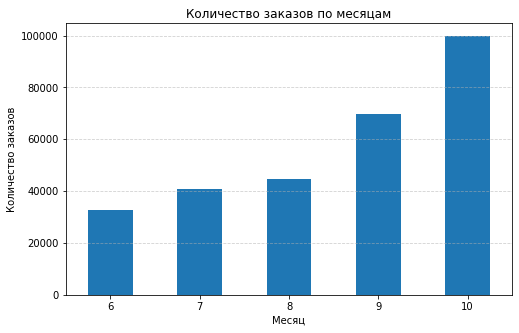

In [ ]:
# Визуализация
plt.figure(figsize=(8,5))
orders_by_month.plot(kind="bar")

plt.title("Количество заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

Налицо увеличение количества заказов с каждым следующим месяцем. Исследуем данные в разрезе времени года по столбцам "event_type_main", "device_type_canonical", "age_limit".

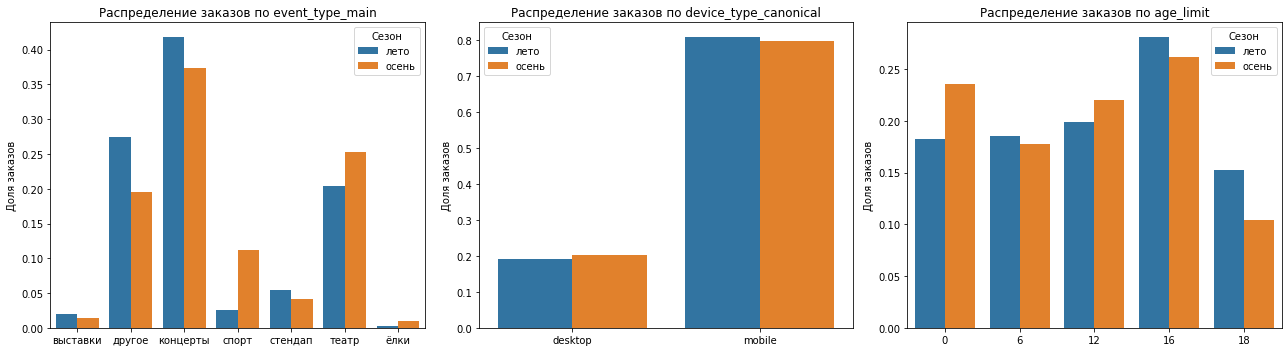

In [ ]:
# Оставляем только лето и осень
df_seasons = data[data["season"].isin(["лето", "осень"])]

# Список категориальных признаков для сравнения
cols_to_check = ["event_type_main", "device_type_canonical", "age_limit"]

# Строим графики для каждой категории
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cols_to_check):
    # Считаем количество заказов и переводим в доли
    dist = (
        df_seasons.groupby(["season", col])["order_id"]
        .count()
        .groupby(level=0).apply(lambda x: x / x.sum())
        .reset_index()
    )
    
    # Сравнение долей по сезонам
    sns.barplot(
        data=dist, 
        x=col, 
        y="order_id", 
        hue="season", 
        ax=ax
    )
    
    ax.set_title(f"Распределение заказов по {col}")
    ax.set_ylabel("Доля заказов")
    ax.set_xlabel("")
    ax.legend(title="Сезон")

plt.tight_layout()
plt.show()

Мы увидели, что действительно летом и осенью изменились потребительские предпочтения касающиеся видов событий. Так летом потребители предпочитают выставки, стендапы и концерты, тогда как осенью предпочтение отдается спортивным мероприятиям, театру и "елкам". Независимо от времени года большинство заказов создаются с мобильных устройств, а не со стационарных ПК. Наиболее популярная возрастная категория это "16", причем ее доля больше остальных независимо от времени года. Наиболее реже встречающаяся категория это возрастная категоря "18", у нее же самая маленькая доля в распределении заказов в разрезе возрастных категорий. Осенью значительно больше мероприятий относится к возрастной категории "0", а летом к возрастной категории "18".

season            лето  осень  change_%
event_type_main                        
выставки         86.39  91.07      5.42
стендап         221.28 232.63      5.13
спорт            51.97  50.01     -3.78
другое           80.63  76.96     -4.55
концерты        297.33 273.80     -7.91
ёлки            274.75 234.20    -14.76
театр           218.71 179.68    -17.85


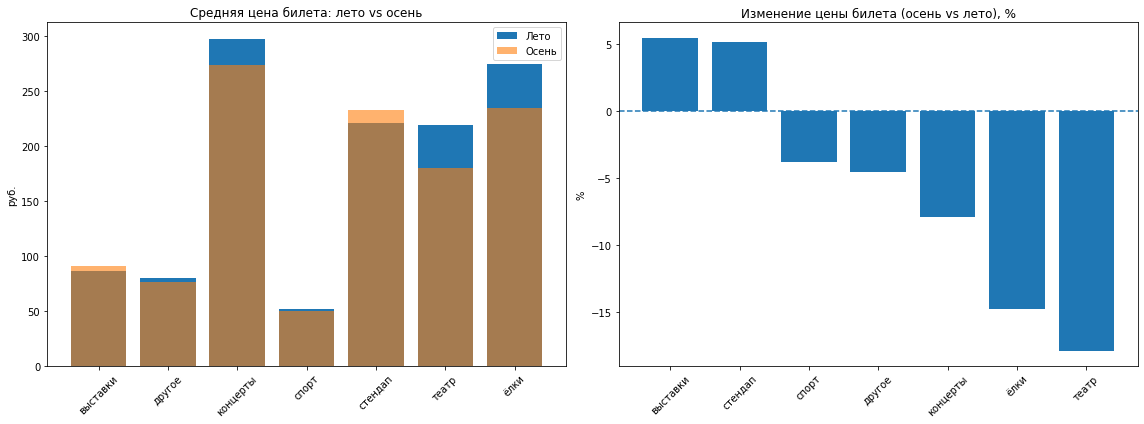

In [ ]:
# 1) Фильтруем сезоны и приводим season к строке, так как ранее бы приводили данные в столбце к типу category
df = data[data["season"].isin(["лето", "осень"])].copy()
df["season"] = df["season"].astype(str)

# 2) Средняя цена билета по типу мероприятия и сезону
mean_ticket = (
    df.groupby(["event_type_main", "season"], observed=True)["one_ticket_revenue_rub"]
      .mean()
      .reset_index()
)
pivot = (
    mean_ticket
      .pivot(index="event_type_main", columns="season", values="one_ticket_revenue_rub")
      .reindex(columns=["лето", "осень"])
)

# 3) Считаем относительное изменение осень vs лето
pivot["change_%"] = np.where(
    pivot["лето"].notna() & (pivot["лето"] != 0),
    (pivot["осень"] - pivot["лето"]) / pivot["лето"] * 100,
    np.nan
)

pivot_sorted = pivot.sort_values("change_%", ascending=False)

print(pivot_sorted.round(2))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) Сравнение средних цен билета летом и осенью по типам мероприятий
axes[0].bar(pivot.index, pivot["лето"], label="Лето")
axes[0].bar(pivot.index, pivot["осень"], bottom=None, alpha=0.6, label="Осень")
axes[0].set_title("Средняя цена билета: лето vs осень")
axes[0].set_ylabel("руб.")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# (2) Процентное изменение (осень относительно лета)
axes[1].bar(pivot_sorted.index, pivot_sorted["change_%"])
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Изменение цены билета (осень vs лето), %")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Мы установили, что летом средняя цена билета выше в категориях "выставки" и "стендап", тогда как осенью цены выше у категорий "конценты", "театр", "елки", "другое", "спорт". Наиболее высокая разница средней цены билета наблюдается у категорий "стендап" (+10%), "концерты" (-10,13%), "елки" (-15,15%), "театр" (-17,74%) - числа приведены относительно лета к осени. 

Изучим активность пользователей осенью 2024 года.

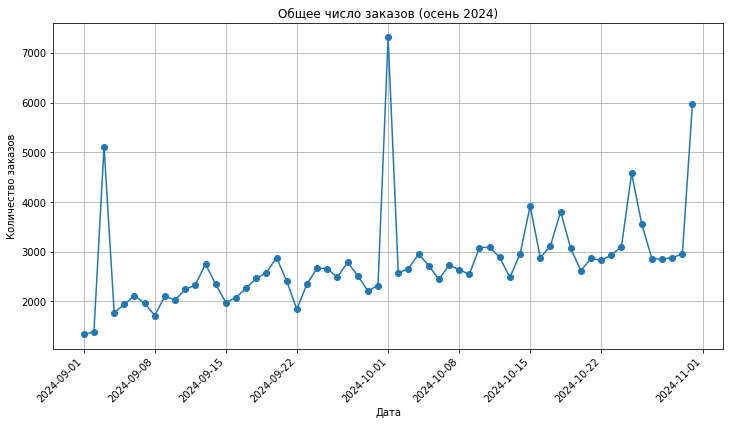

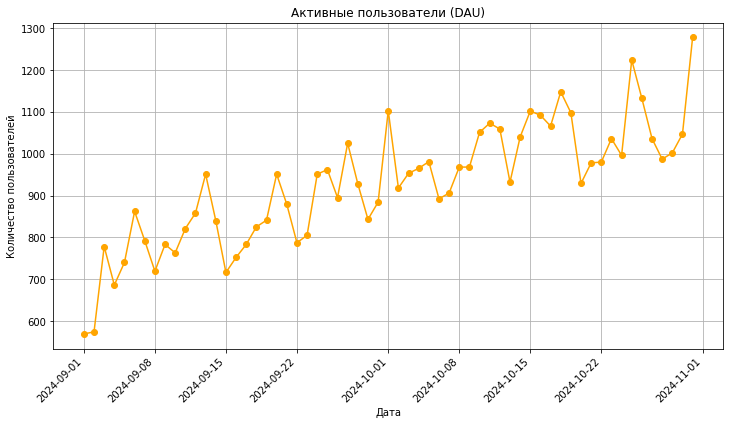

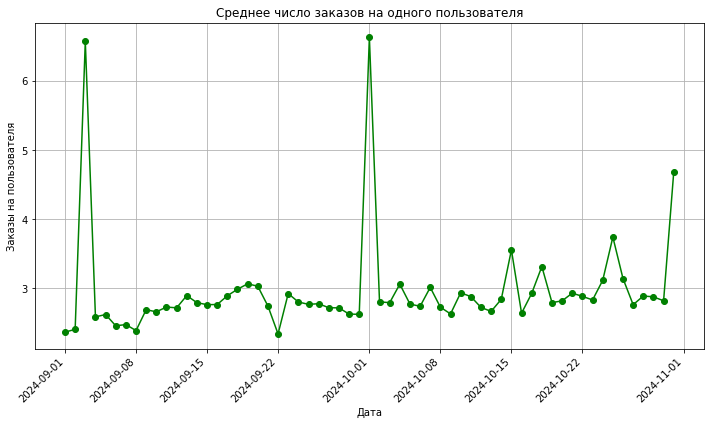

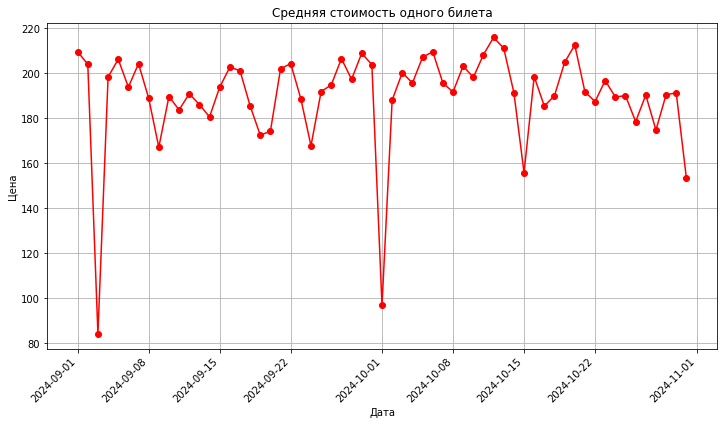

In [ ]:
# фильтруем только осень 2024 года
autumn = data[
    (data['created_dt_msk'].dt.year == 2024) &
    (data['created_dt_msk'].dt.month.isin([9, 10]))
].copy()

# создаём вспомогательную колонку: средняя цена билета в заказе
autumn["ticket_price"] = autumn["revenue"] / autumn["tickets_count"]

# группировка по дням
daily_stats = autumn.groupby(autumn['created_dt_msk'].dt.date).agg(
    orders=("order_id", "count"),
    dau=("user_id", "nunique"),
    avg_ticket_price=("ticket_price", "mean")
).reset_index()

# среднее число заказов на пользователя
daily_stats["orders_per_user"] = daily_stats["orders"] / daily_stats["dau"]

# Число заказов
plt.figure(figsize=(12,6))
plt.plot(daily_stats["created_dt_msk"], daily_stats["orders"], marker="o")
plt.title("Общее число заказов (осень 2024)")
plt.xlabel("Дата")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.show()

# DAU
plt.figure(figsize=(12,6))
plt.plot(daily_stats["created_dt_msk"], daily_stats["dau"], color="orange", marker="o")
plt.title("Активные пользователи (DAU)")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.show()

# Среднее число заказов на пользователя
plt.figure(figsize=(12,6))
plt.plot(daily_stats["created_dt_msk"], daily_stats["orders_per_user"], color="green", marker="o")
plt.title("Среднее число заказов на одного пользователя")
plt.xlabel("Дата")
plt.ylabel("Заказы на пользователя")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.show()

# Средняя стоимость билета
plt.figure(figsize=(12,6))
plt.plot(daily_stats["created_dt_msk"], daily_stats["avg_ticket_price"], color="red", marker="o")
plt.title("Средняя стоимость одного билета")
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.show()

Промежуточный вывод по пользовательской активности осенью.

Общее число заказов постепенно растет в течении осени, также как и число активных пользователей. Среднее число заказов на одного пользователя обычно не превышает трех заказов. На графиках присутствует три дня с аномально высокими показателями общего числа заказов, среднего числа заказов, и аномально низкими значениями средней стоимости одного билета. Все три аномалии совпадают по дням, это 03.09.2024, 01.10.2024, 31.10.2024. Вероятно в эти дни проходила акция, связанная с дешевыми билетами, ч отразилось на общем и среднем количестве заказов.

Теперь проведем исследование в разрезе дней недели (недельная цикличность)

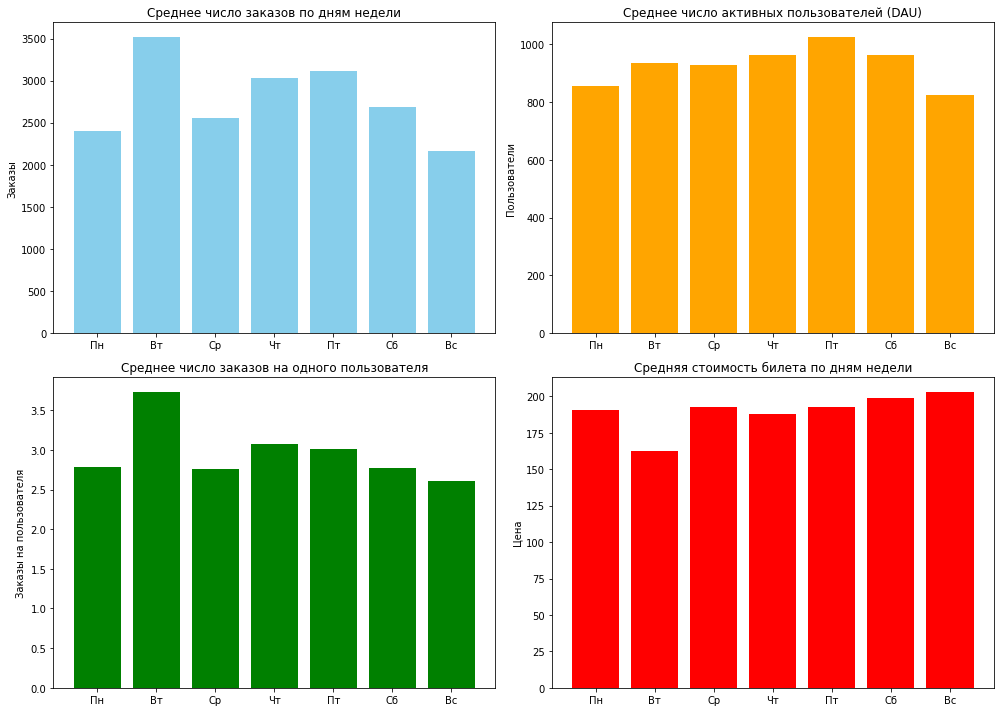

,orders,dau,orders_per_user,avg_ticket_price
Будни,2921.30,940.25,3.07,185.30
Выходные,2409.59,890.12,2.68,201.03


In [ ]:
daily_stats["created_dt_msk"] = pd.to_datetime(daily_stats["created_dt_msk"])
daily_stats["weekday"] = daily_stats["created_dt_msk"].dt.dayofweek

weekday_map = {
    0: "Пн", 1: "Вт", 2: "Ср", 3: "Чт", 4: "Пт", 5: "Сб", 6: "Вс"
}
daily_stats["weekday_name"] = daily_stats["weekday"].map(weekday_map)

# Группируем по дням недели
weekly_stats = daily_stats.groupby("weekday_name").agg({
    "orders": "mean",
    "dau": "mean",
    "orders_per_user": "mean",
    "avg_ticket_price": "mean"
}).reindex(["Пн","Вт","Ср","Чт","Пт","Сб","Вс"])

# Столбчатые графики для каждой метрики
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Список меток для оси X
labels = ["Пн","Вт","Ср","Чт","Пт","Сб","Вс"]
x = range(len(labels))  # 0..6

# Среднее число заказов
axes[0,0].bar(x, weekly_stats["orders"], color="skyblue")
axes[0,0].set_title("Среднее число заказов по дням недели")
axes[0,0].set_ylabel("Заказы")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(labels)

# DAU
axes[0,1].bar(x, weekly_stats["dau"], color="orange")
axes[0,1].set_title("Среднее число активных пользователей (DAU)")
axes[0,1].set_ylabel("Пользователи")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(labels)

# Среднее число заказов на пользователя
axes[1,0].bar(x, weekly_stats["orders_per_user"], color="green")
axes[1,0].set_title("Среднее число заказов на одного пользователя")
axes[1,0].set_ylabel("Заказы на пользователя")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(labels)

# Средняя стоимость билета
axes[1,1].bar(x, weekly_stats["avg_ticket_price"], color="red")
axes[1,1].set_title("Средняя стоимость билета по дням недели")
axes[1,1].set_ylabel("Цена")
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(labels)

plt.tight_layout()
plt.show()

# Общая информация по будням и выходным
daily_stats["is_weekend"] = daily_stats["weekday"].isin([5,6])
weekend_stats = daily_stats.groupby("is_weekend").agg({
    "orders": "mean",
    "dau": "mean",
    "orders_per_user": "mean",
    "avg_ticket_price": "mean"
})

weekend_stats.index = ["Будни", "Выходные"]
display(weekend_stats)

Промежуточный вывод по пользовательской активности по дням недели.

Исследовав данные о пользователях в разрезе недели, можно сделать следующие выводы. Средняя стоимость билетов наиболее низкая во вторник, также во вторник наибольшее среднее количество заказов и среднее число заказов на одного пользователя. предположительно это связано с ценой. Наибольшее количество активных пользователей приходится на четверг, пятницу и субботу, т.е на предвыходные дни и выходные, когда пользователи активно начинают искать как провести время на выходных. 

,unique_events,orders,event_share_%,order_share_%
region_name,,,,
Каменевский регион,5964,90646,26.63,31.53
Североярская область,3806,43855,17.00,15.25
Широковская область,1233,16441,5.51,5.72
Светополянский округ,1075,7575,4.80,2.63
Речиновская область,702,6289,3.14,2.19
Травяная область,683,5042,3.05,1.75
Горицветская область,551,5162,2.46,1.80
Серебринская область,541,5608,2.42,1.95
Яблоневская область,535,6174,2.39,2.15


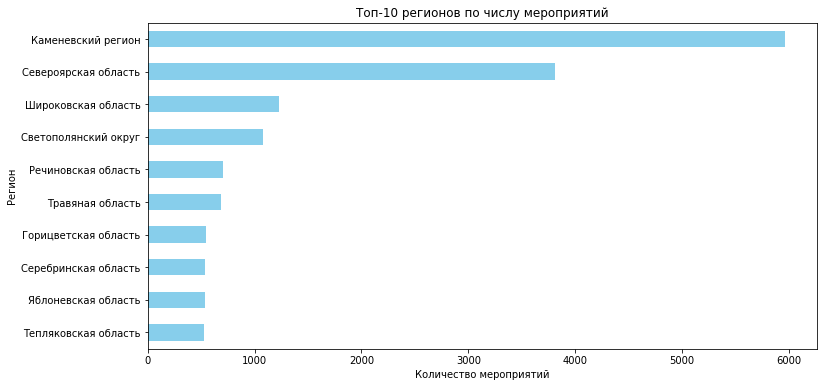

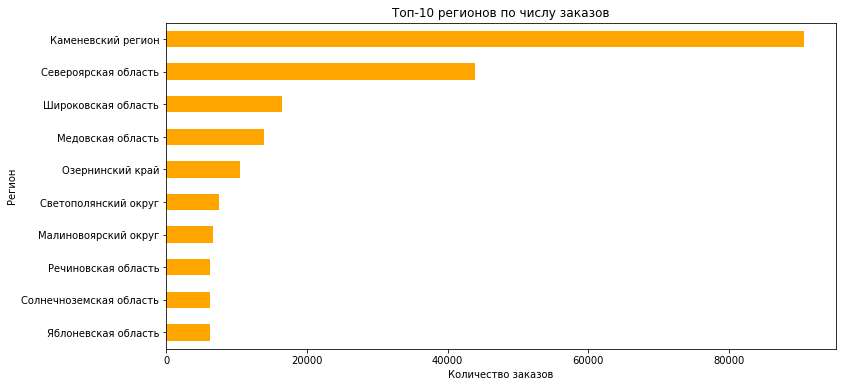

,unique_events,orders,total_revenue,order_share_%,revenue_share_%
venue_name,,,,,
"Мастерская живого действия ""Гардероб"" Лимитед",13,3418,3976788.25,1.19,2.57
"Научно-культурный центр ""Синтез"" Инкорпорэйтед",10,3710,3727696.75,1.29,2.41
"Студия дизайна ""Лестница"" Лимитед",46,3992,3383208.50,1.39,2.19
"Театр кукол ""Огни"" Инкорпорэйтед",57,2568,2651051.50,0.89,1.71
"Клуб хорового пения ""Гардероб"" и партнеры",9,2418,2515552.75,0.84,1.63
"Арт-кафе ""Речка"" Лимитед",8,1393,2475224.50,0.48,1.60
"Клуб настольных игр ""Canvas"" Инкорпорэйтед",17,1809,2309152.50,0.63,1.49
"Картинная галерея ""Светлячок"" Лтд",38,4406,2260231.75,1.53,1.46
"Культурный центр ""Общие"" Групп",98,3868,2184444.25,1.35,1.41


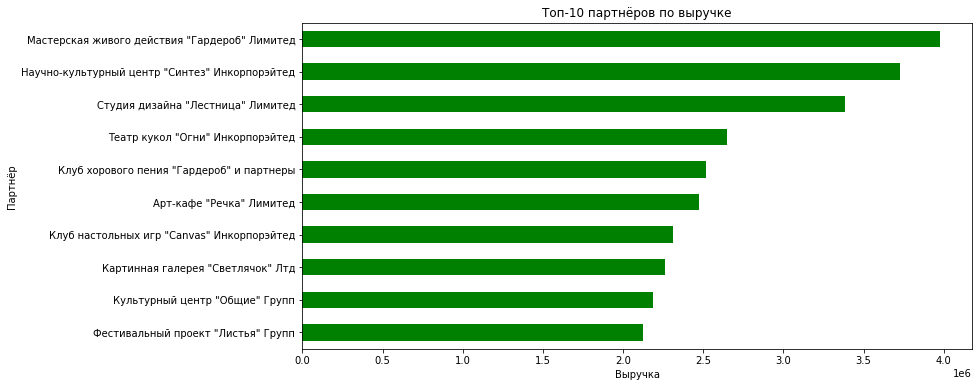

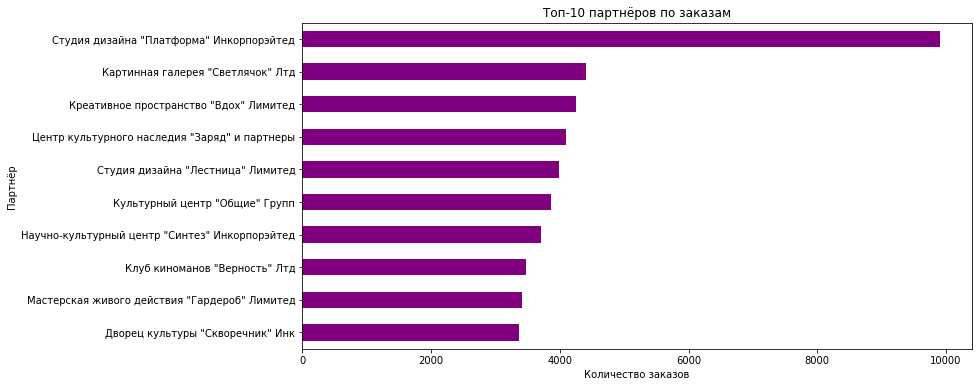

In [ ]:
# Анализ по регионам
region_stats = df.groupby("region_name").agg({
    "event_id": "nunique",   # уникальные мероприятия
    "order_id": "count"      # количество заказов
}).rename(columns={"event_id": "unique_events", "order_id": "orders"})

# Добавляем доли
region_stats["event_share_%"] = (region_stats["unique_events"] / region_stats["unique_events"].sum() * 100).round(2)
region_stats["order_share_%"] = (region_stats["orders"] / region_stats["orders"].sum() * 100).round(2)

# Сортируем по количеству мероприятий
region_stats_sorted = region_stats.sort_values("unique_events", ascending=False)

display(region_stats_sorted.head(10))


# ТОП-10 регионов по числу мероприятий
region_stats.sort_values("unique_events", ascending=False).head(10)["unique_events"].plot(
    kind="barh", figsize=(12,6), color="skyblue"
)
plt.title("Топ-10 регионов по числу мероприятий")
plt.xlabel("Количество мероприятий")
plt.ylabel("Регион")
plt.gca().invert_yaxis()
plt.show()

# ТОП-10 регионов по числу заказов
region_stats.sort_values("orders", ascending=False).head(10)["orders"].plot(
    kind="barh", figsize=(12,6), color="orange"
)
plt.title("Топ-10 регионов по числу заказов")
plt.xlabel("Количество заказов")
plt.ylabel("Регион")
plt.gca().invert_yaxis()
plt.show()


# Анализ по партнерам
partner_stats = df.groupby("venue_name").agg({
    "event_id": "nunique",
    "order_id": "count",
    "revenue": "sum"
}).rename(columns={"event_id": "unique_events", "order_id": "orders", "revenue": "total_revenue"})

# Добавляем доли
partner_stats["order_share_%"] = (partner_stats["orders"] / partner_stats["orders"].sum() * 100).round(2)
partner_stats["revenue_share_%"] = (partner_stats["total_revenue"] / partner_stats["total_revenue"].sum() * 100).round(2)

# Сортировка по выручке
partner_stats_sorted = partner_stats.sort_values("total_revenue", ascending=False)

display(partner_stats_sorted.head(10))

# ТОП-10 партнёров по выручке
partner_stats.sort_values("total_revenue", ascending=False).head(10)["total_revenue"].plot(
    kind="barh", figsize=(12,6), color="green"
)
plt.title("Топ-10 партнёров по выручке")
plt.xlabel("Выручка")
plt.ylabel("Партнёр")
plt.gca().invert_yaxis()
plt.show()

# ТОП-10 партнёров по заказам
partner_stats.sort_values("orders", ascending=False).head(10)["orders"].plot(
    kind="barh", figsize=(12,6), color="purple"
)
plt.title("Топ-10 партнёров по заказам")
plt.xlabel("Количество заказов")
plt.ylabel("Партнёр")
plt.gca().invert_yaxis()
plt.show()


,orders,unique_events,total_revenue,order_share_%,revenue_share_%
service_name,,,,,
Билеты без проблем,63175,4255,25398072.00,21.95,16.75
Мой билет,32734,1304,19240704.00,11.38,12.69
Облачко,26557,2343,19041296.00,9.23,12.56
Лови билет!,41106,4880,17573134.00,14.29,11.59
Весь в билетах,16728,864,17433448.00,5.81,11.50
Билеты в руки,40349,3542,13341694.00,14.02,8.80
Край билетов,6187,252,6630373.00,2.15,4.37
Прачечная,10273,1027,4900985.50,3.57,3.23
Дом культуры,4477,274,4549881.00,1.56,3.00


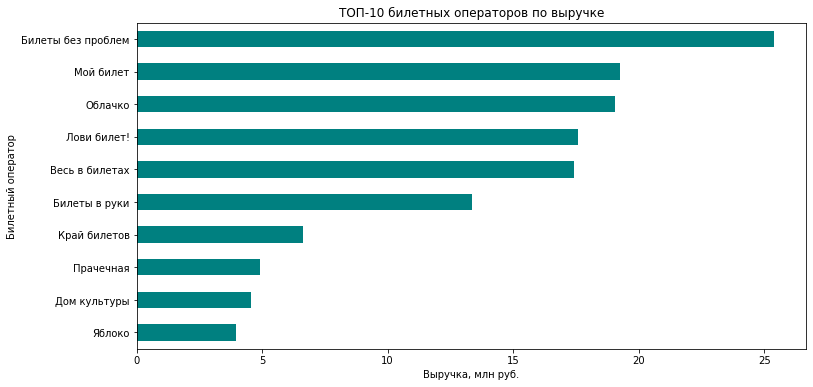

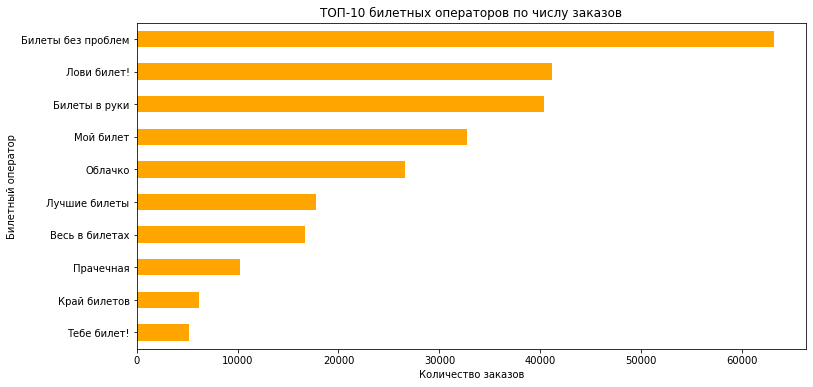

In [ ]:
# Группировка по билетному оператору (service_name)
service_stats = data.groupby("service_name").agg({
    "order_id": "count",       # количество заказов
    "event_id": "nunique",     # уникальные мероприятия
    "revenue_rub": "sum"       # выручка в рублях
}).rename(columns={
    "order_id": "orders",
    "event_id": "unique_events",
    "revenue_rub": "total_revenue"
})

# Добавляем доли
service_stats["order_share_%"] = (service_stats["orders"] / service_stats["orders"].sum() * 100).round(2)
service_stats["revenue_share_%"] = (service_stats["total_revenue"] / service_stats["total_revenue"].sum() * 100).round(2)

# Сортировка по выручке
service_stats_sorted = service_stats.sort_values("total_revenue", ascending=False)

# Выводим ТОП-10
display(service_stats_sorted.head(10))

# Визуализация по выручке
top10 = service_stats_sorted.head(10).copy()

# Делим выручку на 1 млн для отображения на графике
top10["total_revenue_mln"] = top10["total_revenue"] / 1_000_000

# Визуализация
top10["total_revenue_mln"].plot(
    kind="barh", figsize=(12,6), color="teal"
)
plt.title("ТОП-10 билетных операторов по выручке")
plt.xlabel("Выручка, млн руб.")
plt.ylabel("Билетный оператор")
plt.gca().invert_yaxis()
plt.show()

# Визуализация по заказам
service_stats.sort_values("orders", ascending=False).head(10)["orders"].plot(
    kind="barh", figsize=(12,6), color="orange"
)
plt.title("ТОП-10 билетных операторов по числу заказов")
plt.xlabel("Количество заказов")
plt.ylabel("Билетный оператор")
plt.gca().invert_yaxis()
plt.show()

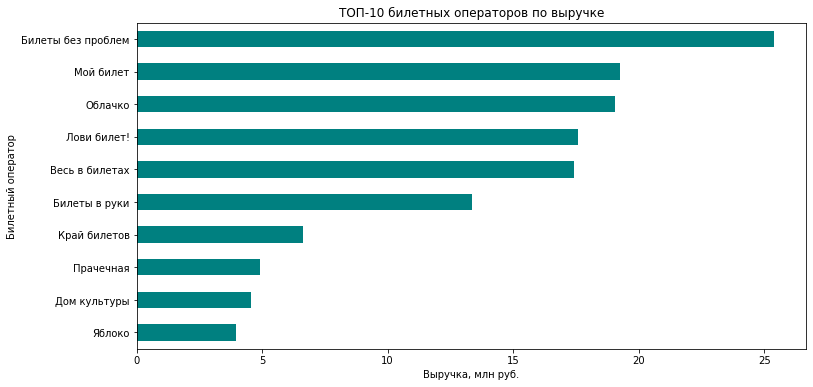

In [ ]:
# ТОП-10 по выручке
top10 = service_stats_sorted.head(10).copy()

# Делим выручку на 1 млн для отображения на графике
top10["total_revenue_mln"] = top10["total_revenue"] / 1_000_000

# Визуализация
top10["total_revenue_mln"].plot(
    kind="barh", figsize=(12,6), color="teal"
)
plt.title("ТОП-10 билетных операторов по выручке")
plt.xlabel("Выручка, млн руб.")
plt.ylabel("Билетный оператор")
plt.gca().invert_yaxis()
plt.show()

Промежуточный вывод.

Среди регионов особо выделяются два региона - это Каменевский регион и Североярская область. На Каменевский регион приходится 26,6% всех проводимых мероприятий и 31,3% от всех заказов. На Североярскую область приходится 17% всех проводимых мероприятий и 15,1% от всех заказов. Данные цифры напорядок выше чем к их ближайшего конкурента Широковской области. Таким образов с совокупности на 2 региона приходится 43,68% от всех проводимых мероприятий и 46,49% всех заказов. В целом регионы идут по выручке и количеству заказов в сходном порядке, то есть выручка и количество заказов в разрезе регионов связаны.


Среди площадок-партнеров наибольшую выручку получили Архитектурное бюро "Секрет" Инк (9478075 рублей, доля от всей выручки 5,21%), Арт-кафе "Речка" Лимитед (7321837 рублей, доля от всей выручки 4.03%), Кладбище искусств "Феномен" Инк (5494655 рублей, доля от всей выручки 3,02%). Интересно, что размер выручки и количества заказов между собой не связан, топ площадок по выручке и топ площадок количеству заказов разные. По количеству заказов на первом месте с большим отрывом от ближайшего конкурента идет Студия дизайна "Платформа" Инкорпорейтед (с количеством заказов близким к 10000), однако эта же студия не входит даже в топ 10 площадок по выручке.

Среди билетных операторов первое место по выручке занимает "Билеты без проблем", который заработал 26,3 млн. рублей (16,75% от всей выручки всех билетных операторов). На данного билетного оператора приходится 21,95% заказов билетов всех операторов.

## Исследовательский анализ данных

Отдельно проверим две гипотезы относительно активности пользователей мобильных и стационарных устройств.

Нулевая гипотеза: среднее количество заказов на одного пользователя мобильного приложения НЕ выше по сравнению с пользователями стационарных устройств

Альтернативная гипотеза: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств

Проверим имеются ли пользователя в обеих группах сразу, чтобы группы оставались гомогенными.

In [ ]:
# Данные только за осень
autumn_data = data[data['season'] == 'осень']

# Сначала создаем столбец orders_per_user в основном DataFrame
autumn_data['orders_per_user'] = autumn_data.groupby('user_id')['order_id'].transform('count')

# Проверяем пересекающихся пользователей
mobile_users = set(autumn_data[autumn_data['device_type_canonical'] == 'mobile']['user_id'])
desktop_users = set(autumn_data[autumn_data['device_type_canonical'] == 'desktop']['user_id'])

# Находим пересекающихся пользователей
overlap_users = mobile_users.intersection(desktop_users)
print(f"Количество пользователей в обеих группах: {len(overlap_users)}")
print(f"Доля от общего числа пользователей: {len(overlap_users)/len(mobile_users.union(desktop_users)):.2%}")

# Удаляем пересекающихся пользователей из анализа
if len(overlap_users) > 0:
    print("Удаляем пользователей, которые есть в обеих группах.")
    autumn_data_clean = autumn_data[~autumn_data['user_id'].isin(overlap_users)]
else:
    autumn_data_clean = autumn_data.copy()
    print("Пересекающихся пользователей не найдено")

Количество пользователей в обеих группах: 3260
Доля от общего числа пользователей: 20.61%
Удаляем пользователей, которые есть в обеих группах.


/tmp/ipykernel_202/2102365248.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  autumn_data['orders_per_user'] = autumn_data.groupby('user_id')['order_id'].transform('count')


Размеры выборок после очистки:
Мобильные пользователи: 31346
Десктопные пользователи: 3201


/opt/conda/lib/python3.9/site-packages/scipy/stats/_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


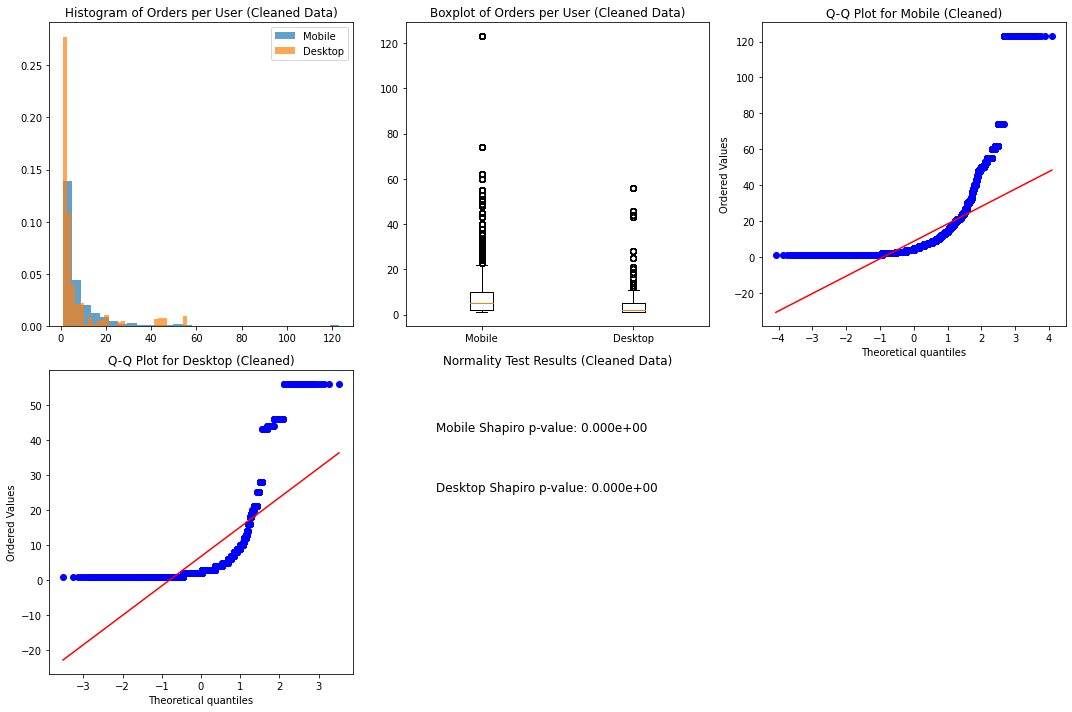

Levene's test p-value (cleaned data): 2.159e-07

Обоснование выбора тестов (очищенные данные):
1. Распределения не нормальные (Mobile Shapiro p-value: 0.000e+00, Desktop Shapiro p-value: 0.000e+00)
2. Дисперсии не равны (Levene's test p-value: 2.159e-07)
3. Выборки независимые (пересекающиеся пользователи удалены)
4. Для ненормальных распределений рекомендуется использовать непараметрический тест Манна-Уитни
5. Дополнительно используем t-тест Уэлча как устойчивый к неравенству дисперсий


In [ ]:
# Пересоздаем выборки с очищенными данными
mobile_orders_clean = autumn_data_clean[autumn_data_clean['device_type_canonical'] == 'mobile']['orders_per_user']
desktop_orders_clean = autumn_data_clean[autumn_data_clean['device_type_canonical'] == 'desktop']['orders_per_user']

print(f"Размеры выборок после очистки:")
print(f"Мобильные пользователи: {len(mobile_orders_clean)}")
print(f"Десктопные пользователи: {len(desktop_orders_clean)}")

# Визуализация распределений
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Гистограммы
axes[0, 0].hist(mobile_orders_clean, bins=30, alpha=0.7, label='Mobile', density=True)
axes[0, 0].hist(desktop_orders_clean, bins=30, alpha=0.7, label='Desktop', density=True)
axes[0, 0].set_title('Histogram of Orders per User (Cleaned Data)')
axes[0, 0].legend()

# Boxplot
axes[0, 1].boxplot([mobile_orders_clean, desktop_orders_clean], labels=['Mobile', 'Desktop'])
axes[0, 1].set_title('Boxplot of Orders per User (Cleaned Data)')

# Q-Q plot для мобильных
stats.probplot(mobile_orders_clean, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot for Mobile (Cleaned)')

# Q-Q plot для десктопных
stats.probplot(desktop_orders_clean, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot for Desktop (Cleaned)')

# Тест Шапиро для нормальности ОЧИЩЕННЫХ данных
_, p_mobile_clean = stats.shapiro(mobile_orders_clean)
_, p_desktop_clean = stats.shapiro(desktop_orders_clean)
axes[1, 1].text(0.1, 0.8, f'Mobile Shapiro p-value: {p_mobile_clean:.3e}', fontsize=12)
axes[1, 1].text(0.1, 0.6, f'Desktop Shapiro p-value: {p_desktop_clean:.3e}', fontsize=12)
axes[1, 1].set_title('Normality Test Results (Cleaned Data)')
axes[1, 1].axis('off')

fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

# Проверка равенства дисперсий для ОЧИЩЕННЫХ данных
levene_stat_clean, levene_p_clean = stats.levene(mobile_orders_clean, desktop_orders_clean)
print(f"Levene's test p-value (cleaned data): {levene_p_clean:.3e}")

# Обоснование выбора тестов для ОЧИЩЕННЫХ данных
print("\nОбоснование выбора тестов (очищенные данные):")
print(f"1. Распределения не нормальные (Mobile Shapiro p-value: {p_mobile_clean:.3e}, Desktop Shapiro p-value: {p_desktop_clean:.3e})")
print(f"2. Дисперсии не равны (Levene's test p-value: {levene_p_clean:.3e})")
print("3. Выборки независимые (пересекающиеся пользователи удалены)")
print("4. Для ненормальных распределений рекомендуется использовать непараметрический тест Манна-Уитни")
print("5. Дополнительно используем t-тест Уэлча как устойчивый к неравенству дисперсий")

In [ ]:
# t-тест Уэлча с очищенными данными
t_stat_clean, p_value_t_clean = stats.ttest_ind(mobile_orders_clean, desktop_orders_clean, equal_var=False)
p_value_t_one_sided_clean = p_value_t_clean / 2 if t_stat_clean > 0 else 1 - (p_value_t_clean / 2)

# U-тест Манна–Уитни с очищенными данными
u_stat_clean, p_value_u_clean = stats.mannwhitneyu(mobile_orders_clean, desktop_orders_clean, alternative='greater')

print("t-тест Уэлча (очищенные данные):")
print(f"t-статистика: {t_stat_clean}, p-value: {p_value_t_one_sided_clean}")

print("\nU-критерий Манна–Уитни (очищенные данные):")
print(f"U-статистика: {u_stat_clean}, p-value: {p_value_u_clean}")

t-тест Уэлча (очищенные данные):
t-статистика: 9.24936987918559, p-value: 1.779754605436058e-20

U-критерий Манна–Уитни (очищенные данные):
U-статистика: 62762093.0, p-value: 4.2202388235481945e-123


В обоих тестах p-value < 0.05, значит нулевая гипотеза (что среднее число заказов у мобильных пользователей не выше) отвергается. Альтернативная гипотеза подтверждается:
пользователи мобильных устройств совершают больше заказов на одного пользователя, чем пользователи десктопа.

Проверим вторую гипотезу.

Нулевая гипотеза: среднее время между заказами пользователей мобильных приложений НЕ выше по сравнению с пользователями стационарных устройств.

Альтернативная гипотеза: среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Проведем проверку на пересекающихся пользователей, и проведем статистические тесты Манна-Уитни и тест Уэлча. Нормальность данных проверять не будем, так как мы выяснили ранее, что данные не имеют нормального распределения и одинаковой дисперсии.

In [ ]:
# Данные только за осень и с ненулевым временем между заказами
autumn_data_days = data[(data['season'] == 'осень') & (data['days_since_prev'].notna())]

# Проверяем пересекающихся пользователей для времени между заказами
mobile_days_users = set(autumn_data_days[autumn_data_days['device_type_canonical'] == 'mobile']['user_id'])
desktop_days_users = set(autumn_data_days[autumn_data_days['device_type_canonical'] == 'desktop']['user_id'])

overlap_days_users = mobile_days_users.intersection(desktop_days_users)
print(f"Количество пользователей в обеих группах (время между заказами): {len(overlap_days_users)}")
print(f"Доля от общего числа пользователей: {len(overlap_days_users)/len(mobile_days_users.union(desktop_days_users)):.2%}")

# Удаляем пересекающихся пользователей
if len(overlap_days_users) > 0:
    print("Удаляем пользователей, которые есть в обеих группах.")
    autumn_data_days_clean = autumn_data_days[~autumn_data_days['user_id'].isin(overlap_days_users)]
else:
    autumn_data_days_clean = autumn_data_days.copy()
    print("Пересекающихся пользователей не найдено")

# Создаем очищенные выборки
mobile_days_clean = autumn_data_days_clean[autumn_data_days_clean['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_days_clean = autumn_data_days_clean[autumn_data_days_clean['device_type_canonical'] == 'desktop']['days_since_prev']

print(f"Размеры выборок после очистки:")
print(f"Мобильные пользователи: {len(mobile_days_clean)}")
print(f"Десктопные пользователи: {len(desktop_days_clean)}")

# t-тест Уэлча с очищенными данными (односторонний)
t_stat_days_clean, p_value_t_days_clean = stats.ttest_ind(mobile_days_clean, desktop_days_clean, equal_var=False, nan_policy='omit')
p_value_t_one_sided_days_clean = p_value_t_days_clean / 2 if t_stat_days_clean > 0 else 1 - (p_value_t_days_clean / 2)

# U-тест Манна–Уитни с очищенными данными (односторонний, alternative='greater')
u_stat_days_clean, p_value_u_days_clean = stats.mannwhitneyu(mobile_days_clean, desktop_days_clean, alternative='greater')

print("t-тест Уэлча (время между заказами, очищенные данные):")
print(f"t-статистика: {t_stat_days_clean}, p-value: {p_value_t_one_sided_days_clean}")

print("\nU-критерий Манна–Уитни (время между заказами, очищенные данные):")
print(f"U-статистика: {u_stat_days_clean}, p-value: {p_value_u_days_clean}")

Количество пользователей в обеих группах (время между заказами): 3036
Доля от общего числа пользователей: 27.12%
Удаляем пользователей, которые есть в обеих группах.
Размеры выборок после очистки:
Мобильные пользователи: 24882
Десктопные пользователи: 2279
t-тест Уэлча (время между заказами, очищенные данные):
t-статистика: -5.42825694604369, p-value: 0.9999999688739233

U-критерий Манна–Уитни (время между заказами, очищенные данные):
U-статистика: 30016472.0, p-value: 3.819257482973148e-07


Оба теста дали p-value < 0.05, значит нулевая гипотеза (что среднее время между заказами у мобильных < у десктопа) отвергается. Подтверждается альтернативная гипотеза:
пользователи мобильных устройств в среднем дольше ждут между заказами, чем пользователи стационарных устройств.

## Общий вывод и рекомендации

1. Информация о данных

В ходе исследования проанализированы данные о 290 849 заказах билетов через сервис Яндекс Афиша за 2024 год. Данные включали информацию о заказах, мероприятиях и курсе тенге к рублю для корректного сравнения выручки.

2. Основные результаты анализа типов мероприятий и цен в разные периоды

Востребованность мероприятий:

Наиболее популярные типы мероприятий: концерты, театральные постановки и спортивные события.

Летом наблюдается рост спроса на выставки и стендапы, осенью — на спортивные мероприятия, театр и "ёлки".

Динамика цен:

Средняя цена билета осенью снизилась на 10-17% для ключевых категорий (концерты, театр, ёлки) по сравнению с летним периодом.

Наибольшее падение цены отмечено в категории "театр" (-17.7%).

3. Пользовательская активность:

Выявлена ярко выраженная недельная цикличность: пик активности приходится на вторник (максимальное число заказов), а также на четверг-субботу (максимальное число активных пользователей).

Обнаружены три аномальных дня (03.09, 01.10, 31.10) с резким ростом заказов и снижением среднего чека, что свидетельствует о вероятном проведении акций.

4. Региональные лидеры:

Каменевский регион (31.3% заказов) и Североярская область (15.1% заказов) являются безоговорочными лидерами, формируя почти половину всего объема заказов.

Выручка распределена пропорционально количеству заказов по регионам.

5. Партнёры-лидеры:

По выручке лидируют: Архитектурное бюро "Секрет" Инк (5.2% выручки), Арт-кафе "Речка" Лимитед (4.0%).

По количеству заказов лидирует Студия дизайна "Платформа" Инкорпорейтед (близко к 10 000 заказов), что не коррелирует с выручкой, указывая на различную ценовую политику партнёров.

6. Результаты проверки гипотез

Гипотеза 1: Пользователи мобильных устройств совершают больше заказов на одного пользователя, чем пользователи десктопа (подтверждена, p-value < 0.05).

Гипотеза 2: Пользователи мобильных устройств реже совершают повторные покупки (больше времени между заказами), чем пользователи десктопа (подтверждена, p-value < 0.05).

7. Рекомендации

- Усилить присутствие в регионах-лидерах (особенно обратить внимание на Каменевский регион, Североярская область), где сконцентрирована основная аудитория.
- Разработать партнёрскую программу: для партнёров с высоким объемом, но низкой выручкой предложить события с более высоким средним чеком.
- Сезонное ценообразование: учесть осеннее снижение цен при планировании на следующий год.
- Провести дополнительное исследование для понимания причин более редких покупок у мобильной аудитории несмотря на более высокую конверсию.
- Скорректировать маркетинговую активность на вторник (день максимальной конверсии) и предвыходные и выходные дни (четверг-суббота) для увеличения охвата.
- Проанализировать успешный опыт акций в дни 03.09, 01.10, 31.10 и рассмотреть возможность их регулярного проведения для стимулирования спроса.
- Разработать программу лояльности для пользователей мобильных устройств, чтобы сократить время между их повторными покупками.